<h1>6 практическая</h1>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
# Загрузка датасета
data = pd.read_csv("data/steam-200k.csv", names=["user_id", "game_title", "behavior", "value", "unused"], header=None)
data.drop(columns=["unused"], inplace=True)

In [3]:
data['purchase_value'] = data.apply(lambda row: row['value'] if row['behavior'] == 'purchase' else 0, axis=1)
data['play_value'] = data.apply(lambda row: row['value'] if row['behavior'] == 'play' else 0, axis=1)

In [4]:
data['play_value_norm'] = np.log1p(data['play_value'])  # Логарифмическая нормализация

In [5]:
data['combined_value'] = 2 * data['purchase_value'] + 1 * data['play_value_norm']

In [6]:
data_agg = data.pivot_table(
    values="combined_value",
    index="user_id",
    columns="game_title",
    aggfunc="sum"
).fillna(0)

In [7]:
# Item-based подход (пример)
similarity_matrix = pd.DataFrame(cosine_similarity(data_agg.T), index=data_agg.columns, columns=data_agg.columns)
print("Item-based Similarity Matrix:")
print(similarity_matrix.head())

Item-based Similarity Matrix:
game_title                                          007 Legends  0RBITALIS  \
game_title                                                                   
007 Legends                                                 1.0   0.000000   
0RBITALIS                                                   0.0   1.000000   
1... 2... 3... KICK IT! (Drop That Beat Like an...          0.0   0.000000   
10 Second Ninja                                             0.0   0.427679   
10,000,000                                                  0.0   0.000000   

game_title                                          1... 2... 3... KICK IT! (Drop That Beat Like an Ugly Baby)  \
game_title                                                                                                       
007 Legends                                                                                       0.0            
0RBITALIS                                                                        

In [8]:
# User-based подход (пример)
user_similarity_matrix = pd.DataFrame(cosine_similarity(data_agg), index=data_agg.index, columns=data_agg.index)
print("User-based Similarity Matrix:")
print(user_similarity_matrix.head())

User-based Similarity Matrix:
user_id  5250       76767      86540      103360     144736     181212     \
user_id                                                                     
5250      1.000000   0.261224   0.210881   0.363229   0.406053   0.492718   
76767     0.261224   1.000000   0.144767   0.296679   0.335164   0.358181   
86540     0.210881   0.144767   1.000000   0.225148   0.251692   0.229119   
103360    0.363229   0.296679   0.225148   1.000000   0.894317   0.728549   
144736    0.406053   0.335164   0.251692   0.894317   1.000000   0.816484   

user_id  229911     298950     299153     381543     ...  309262440  \
user_id                                              ...              
5250      0.344033   0.233329   0.460477   0.362328  ...   0.130425   
76767     0.494547   0.139599   0.308842   0.338090  ...   0.000000   
86540     0.143975   0.259460   0.214070   0.224589  ...   0.000000   
103360    0.529518   0.094096   0.845154   0.981612  ...   0.000000   
1447

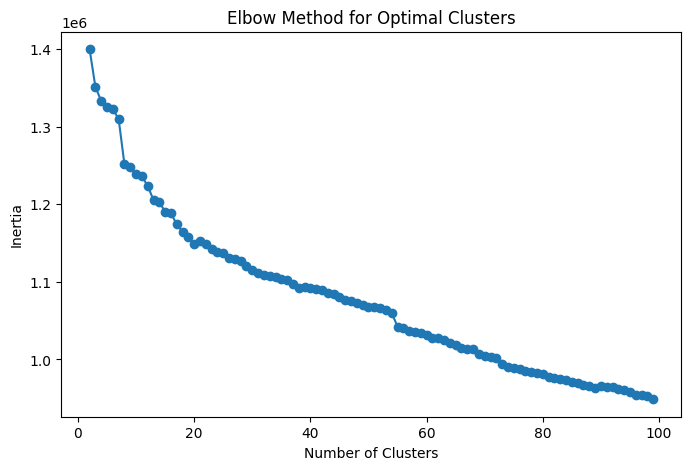

In [9]:
# Метод локтя для определения оптимального количества кластеров
inertia = []
range_clusters = range(2, 100)
for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_agg.fillna(0))
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range_clusters, inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [9]:
# Кластеризация
kmeans = KMeans(n_clusters=30, random_state=42)
kmeans_labels = kmeans.fit_predict(data_agg)
data_agg['cluster'] = kmeans_labels
print("Cluster assignments:")
print(data_agg['cluster'].value_counts())

Cluster assignments:
cluster
28    5133
1     2310
6     1141
2      695
13     470
0      394
18     310
11     294
14     224
20     221
7      200
8      195
27     158
23     128
10     107
19     106
9       88
4       81
22      66
12      37
29      21
25       6
26       1
15       1
3        1
16       1
24       1
21       1
17       1
5        1
Name: count, dtype: int64


In [11]:
# Подбор параметра n_components для SVD
svd_scores = []
n_components_range = range(2, 50)
for n in n_components_range:
    svd = TruncatedSVD(n_components=n, random_state=42)
    svd.fit(data_agg.drop(columns=['cluster']))
    svd_scores.append(svd.explained_variance_ratio_.sum())

optimal_svd_components = n_components_range[np.argmax(svd_scores)]
print(f"Optimal number of components for SVD: {optimal_svd_components}")

Optimal number of components for SVD: 49


In [10]:
# Матричная факторизация с SVD
svd = TruncatedSVD(n_components=49, random_state=42)
user_svd_factors = svd.fit_transform(data_agg.drop(columns=['cluster']))
game_svd_factors = svd.components_.T

In [ ]:
# Подбор параметра n_components для NMF
nmf_scores = []
for n in n_components_range:
    nmf = NMF(n_components=n, random_state=42, init='random')
    nmf.fit(data_agg.drop(columns=['cluster']))
    nmf_scores.append(-nmf.reconstruction_err_)

In [11]:
# Матричная факторизация с NMF
nmf = NMF(n_components=49, random_state=42)
user_nmf_factors = nmf.fit_transform(data_agg.drop(columns=['cluster']))
game_nmf_factors = nmf.components_.T

In [12]:
# 1. Корреляция Пирсона
pearson_correlation = data_agg.corr(method='pearson')
print("Pearson Correlation Matrix:")
print(pearson_correlation.head())

Pearson Correlation Matrix:
game_title                                          007 Legends  0RBITALIS  \
game_title                                                                   
007 Legends                                            1.000000  -0.000140   
0RBITALIS                                             -0.000140   1.000000   
1... 2... 3... KICK IT! (Drop That Beat Like an...    -0.000204  -0.000353   
10 Second Ninja                                       -0.000190   0.427497   
10,000,000                                            -0.000081  -0.000140   

game_title                                          1... 2... 3... KICK IT! (Drop That Beat Like an Ugly Baby)  \
game_title                                                                                                       
007 Legends                                                                                 -0.000204            
0RBITALIS                                                                          

In [13]:
# 2. Результаты кластеризации
cluster_scores = silhouette_score(data_agg.drop(columns=['cluster']), kmeans.labels_)
print(f"Silhouette Score for Clustering: {cluster_scores}")

Silhouette Score for Clustering: 0.10875056231355303


In [14]:
# 3. SVD/NMF
print("Explained Variance by SVD:", svd.explained_variance_ratio_.sum())
nmf_reconstruction_error = nmf.reconstruction_err_
print("Reconstruction Error for NMF:", nmf_reconstruction_error)


Explained Variance by SVD: 0.5183657361158903
Reconstruction Error for NMF: 870.6603545830594


In [15]:
# Матрица U (пользователи -> скрытые факторы)
print("\nМатрица U (пользователи -> скрытые факторы):")
print(svd.components_)

# Матрица S (сингулярные значения)
print("\nМатрица S (сингулярные значения):")
print(np.diag(svd.singular_values_))

# Матрица VT (скрытые факторы -> элементы)
print("\nМатрица VT (скрытые факторы -> элементы):")
print(svd.components_)


Матрица U (пользователи -> скрытые факторы):
[[ 7.67499904e-05  4.38046871e-04  2.20794373e-03 ...  1.09669149e-03
   1.89877841e-02  8.49871261e-04]
 [-1.10275984e-04 -3.47669533e-04 -1.28721156e-03 ... -4.15509769e-04
  -1.25664235e-03 -7.11071343e-04]
 [-1.64245166e-04  7.83157578e-05 -1.91468939e-03 ...  9.86491070e-04
   3.01940316e-02  2.59575860e-04]
 ...
 [ 8.17156146e-04 -7.04082485e-04  2.47542810e-03 ...  7.04423077e-04
  -1.26518341e-02 -6.31556065e-04]
 [ 5.45838850e-04 -1.46864845e-03 -1.37365755e-02 ... -4.01794185e-03
  -1.95235623e-02  2.29417410e-03]
 [ 7.66751447e-04  1.16771819e-03 -2.15525034e-03 ... -4.37461391e-03
   3.42362107e-02  1.64655127e-03]]

Матрица S (сингулярные значения):
[[462.58799915   0.           0.         ...   0.           0.
    0.        ]
 [  0.         331.36920683   0.         ...   0.           0.
    0.        ]
 [  0.           0.         240.32784327 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         